In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

In [2]:
# 1. LOAD DATASET (Menggunakan file yang sudah kita seleksi sebelumnya)
file_path = 'Dataset 5 ops + cems.xlsx'
df_raw_1 = pd.read_excel(file_path)

In [3]:
df_raw_1

,Main steam flow (t/h),Main steam temperature (boiler side) (℃),Main steam pressure (boiler side) (Mpa),Reheat steam temperature (boiler side) (℃),Superheater desuperheating water flow (t/h),Reheater desuperheating water flow (t/h),Feedwater temperature (℃),Feedwater flow (t/h),Flue gas temperature (℃),Boiler oxygen level (%),...,Coal Flow (t/h),NPHR (Kcal/Kwh),Gross Load (MW),Nett Load (MW),HHV (Kcal/Kg),Pressure HRH,Temperature HRH,Spray reheat pressure,Spray reheat temperature,Boiler Eff (%)
0,983.364461,568.098974,15.970471,566.719831,128.135595,0.935145,258.021498,1035.752935,130.708067,3.828501,...,192.41,2607.270106,344.56,323.93,4389.444444,2.29,566.36,5.50,159.91,77.915748
1,903.312848,568.023808,14.907765,563.985723,119.628420,1.944743,253.733859,964.867360,129.803971,3.659717,...,181.37,2687.121676,316.02,296.27,4389.444444,2.10,565.00,5.11,149.95,76.294873
2,903.734408,568.650337,14.869165,565.670929,110.785154,1.437433,253.613525,959.486415,127.860081,3.561764,...,178.47,2663.032090,314.22,294.17,4389.444444,2.09,565.63,5.08,149.38,77.886219
3,877.767639,568.262788,14.422768,564.237198,97.307475,0.983420,252.217335,938.427597,129.812856,3.905170,...,172.09,2651.943177,304.68,284.84,4389.444444,2.03,564.09,4.92,141.10,78.367624
4,921.238833,568.102547,15.204717,565.474856,93.665703,0.798093,254.271976,974.631602,130.218360,3.879849,...,181.74,2651.524408,320.94,300.86,4389.444444,2.13,565.75,5.23,148.33,77.856369
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
544,963.383357,567.188810,15.563528,564.490362,89.382077,3.987283,257.473513,970.169352,124.009406,3.292357,...,172.99,2362.587163,329.71,310.26,4237.333333,2.22,565.60,5.37,155.64,89.855113
545,890.941643,567.664945,14.386963,565.543734,83.488775,1.646984,253.524998,895.883235,123.268547,3.498842,...,164.77,2421.984297,307.55,288.27,4237.333333,2.08,565.79,4.96,150.91,88.052730
546,882.807854,567.590635,14.158093,566.011767,102.147880,3.174934,252.915498,886.779790,124.640201,3.468605,...,169.38,2522.739965,303.77,284.50,4237.333333,2.05,565.84,4.84,149.64,85.018900
547,917.612111,567.520828,14.621877,566.072634,106.958025,6.522704,254.775243,915.165001,127.187321,3.320881,...,179.69,2584.543200,314.09,294.60,4237.333333,2.12,566.30,5.00,153.37,83.295960


In [4]:
# Pisahkan fitur dari target (Analisis VIF hanya dilakukan pada fitur input)
target_cols = ['NPHR (Kcal/Kwh)', 'Boiler Eff (%)']
X_raw = df_raw_1.drop(columns=target_cols)

In [5]:
X_raw

,Main steam flow (t/h),Main steam temperature (boiler side) (℃),Main steam pressure (boiler side) (Mpa),Reheat steam temperature (boiler side) (℃),Superheater desuperheating water flow (t/h),Reheater desuperheating water flow (t/h),Feedwater temperature (℃),Feedwater flow (t/h),Flue gas temperature (℃),Boiler oxygen level (%),...,Refference Temperature (°C),Flue Gas in Temperature (°C),Coal Flow (t/h),Gross Load (MW),Nett Load (MW),HHV (Kcal/Kg),Pressure HRH,Temperature HRH,Spray reheat pressure,Spray reheat temperature
0,983.364461,568.098974,15.970471,566.719831,128.135595,0.935145,258.021498,1035.752935,130.708067,3.828501,...,35.0,350.96,192.41,344.56,323.93,4389.444444,2.29,566.36,5.50,159.91
1,903.312848,568.023808,14.907765,563.985723,119.628420,1.944743,253.733859,964.867360,129.803971,3.659717,...,33.0,350.79,181.37,316.02,296.27,4389.444444,2.10,565.00,5.11,149.95
2,903.734408,568.650337,14.869165,565.670929,110.785154,1.437433,253.613525,959.486415,127.860081,3.561764,...,33.0,350.13,178.47,314.22,294.17,4389.444444,2.09,565.63,5.08,149.38
3,877.767639,568.262788,14.422768,564.237198,97.307475,0.983420,252.217335,938.427597,129.812856,3.905170,...,33.0,349.91,172.09,304.68,284.84,4389.444444,2.03,564.09,4.92,141.10
4,921.238833,568.102547,15.204717,565.474856,93.665703,0.798093,254.271976,974.631602,130.218360,3.879849,...,34.0,354.42,181.74,320.94,300.86,4389.444444,2.13,565.75,5.23,148.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
544,963.383357,567.188810,15.563528,564.490362,89.382077,3.987283,257.473513,970.169352,124.009406,3.292357,...,27.0,361.97,172.99,329.71,310.26,4237.333333,2.22,565.60,5.37,155.64
545,890.941643,567.664945,14.386963,565.543734,83.488775,1.646984,253.524998,895.883235,123.268547,3.498842,...,27.5,360.27,164.77,307.55,288.27,4237.333333,2.08,565.79,4.96,150.91
546,882.807854,567.590635,14.158093,566.011767,102.147880,3.174934,252.915498,886.779790,124.640201,3.468605,...,27.5,357.56,169.38,303.77,284.50,4237.333333,2.05,565.84,4.84,149.64
547,917.612111,567.520828,14.621877,566.072634,106.958025,6.522704,254.775243,915.165001,127.187321,3.320881,...,28.0,357.98,179.69,314.09,294.60,4237.333333,2.12,566.30,5.00,153.37


In [6]:
# # 2. Preprocessing Dasar
# # Menghilangkan kolom dengan variansi nol (konstanta) yang bisa merusak VIF
# X_raw = X_raw.loc[:, X_raw.var() > 0]
# X_raw = X_raw.fillna(X_raw.median())

In [7]:
# 2. Normalisasi (Z-Score Scaling)
# Ini wajib karena VIF didasarkan pada regresi; perbedaan skala (misal Pressure vs Flow) 
# akan mengacaukan perhitungan jika tidak dinormalisasi.
scaler = StandardScaler()
X_scaled_values = scaler.fit_transform(X_raw)
X_scaled = pd.DataFrame(X_scaled_values, columns=X_raw.columns)

In [8]:
# 3. Perhitungan VIF untuk SEMUA fitur
def calculate_all_vif(data_frame):
    vif_data = pd.DataFrame()
    vif_data["Feature"] = data_frame.columns
    
    vif_list = []
    for i in range(len(data_frame.columns)):
        try:
            vif = variance_inflation_factor(data_frame.values, i)
            vif_list.append(vif)
        except Exception as e:
            # Jika ada varians nol, VIF akan menghasilkan nilai tak terhingga (inf)
            vif_list.append(np.inf)
            
    vif_data["VIF"] = vif_list
    return vif_data.sort_values(by="VIF", ascending=False)

In [9]:
# 1. Atur Pandas agar menampilkan 2 angka di belakang koma (tanpa eksponen)
pd.set_option('display.float_format', lambda x: '{:.2f}'.format(x))

In [10]:
# Eksekusi perhitungan
vif_results = calculate_all_vif(X_scaled)

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [11]:
vif_results

,Feature,VIF
27,Flow rate (KNm3/h),inf
24,Velocity (m/s),inf
12,Reheat steam temperature (turbine side) (℃),6009841.81
0,Main steam flow (t/h),113652.24
2,Main steam pressure (boiler side) (Mpa),84669.31
11,Main steam pressure (turbine side) (MPa),66155.46
3,Reheat steam temperature (boiler side) (℃),54170.24
15,High exhaust pressure (Mpa),40872.57
13,Reheat steam pressure (turbine side) (MPa),31463.71
16,Feedwater pressure (MPa),6033.54


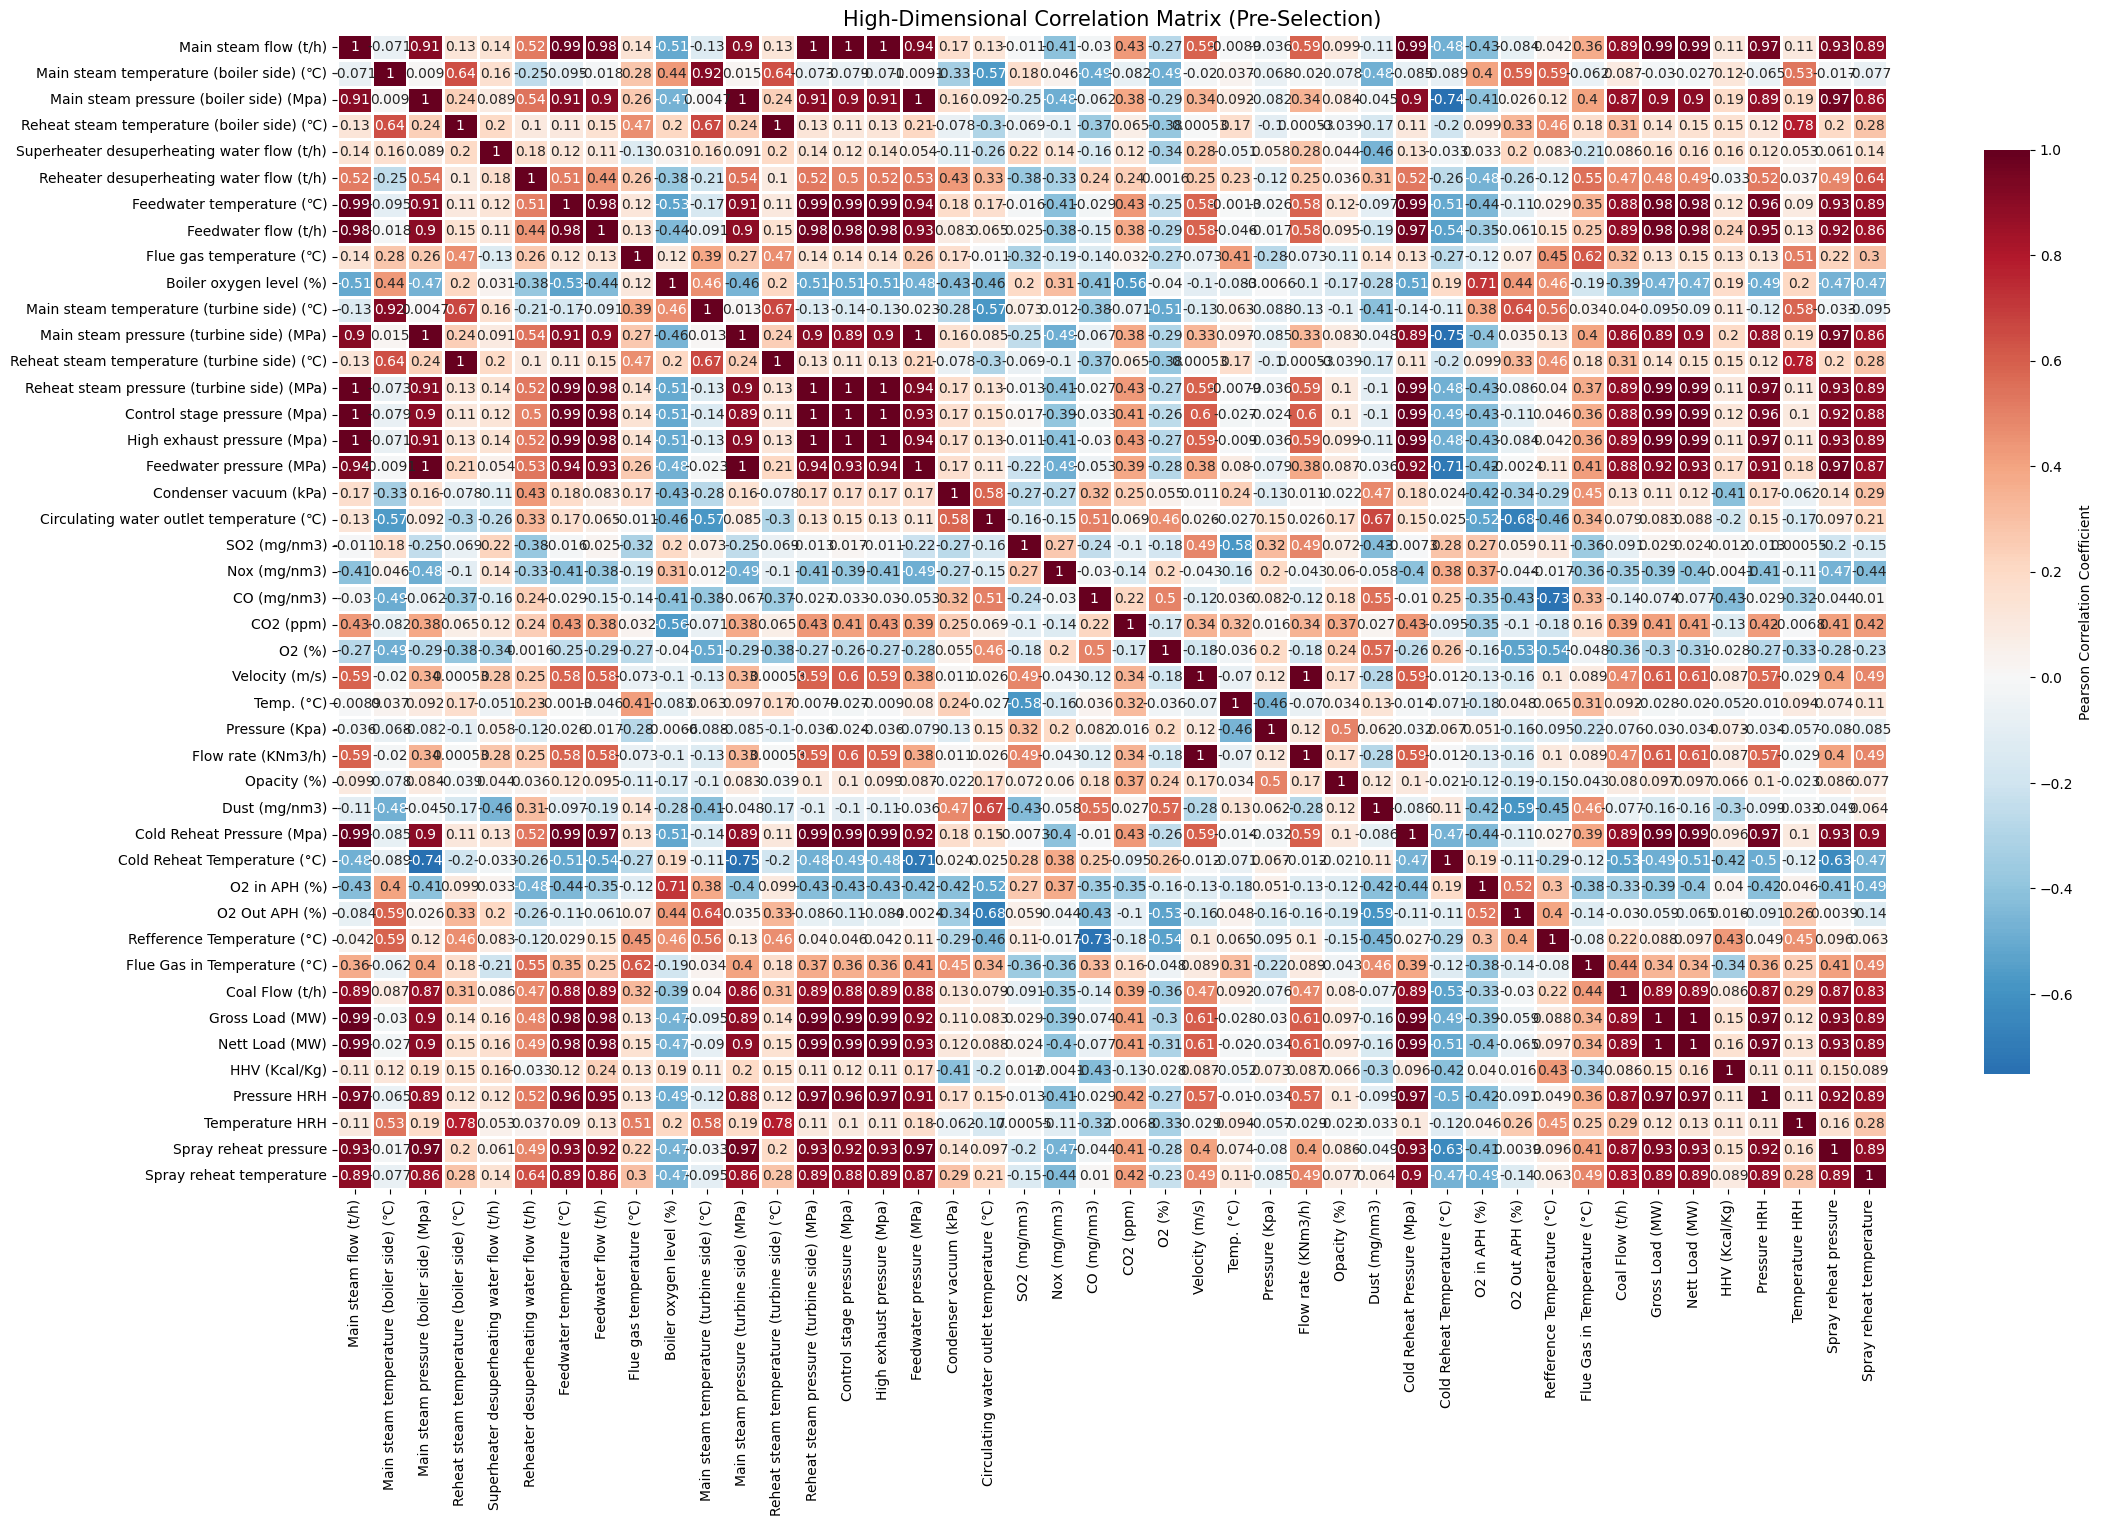

In [12]:
# A. Heatmap Korelasi (Matriks Kompleks)
plt.figure(figsize=(25, 15))
mask = np.tril(np.ones_like(X_scaled.corr(), dtype=bool))
sns.heatmap(X_scaled.corr(), 
            mask=None,          # Menampilkan format rectangle penuh
            annot=True,        # False karena 33 fitur terlalu padat untuk angka
            cmap='RdBu_r',      # Red-Blue (Merah = Positif, Biru = Negatif)
            center=0,           # Putih adalah korelasi 0
            linewidths=1,     # Memberikan garis tipis antar kotak (rectangle)
            linecolor='white',
            square=False,       # Memaksa format mengikuti aspek rasio figsize
            cbar_kws={"shrink": .8, "label": "Pearson Correlation Coefficient"})
plt.title('High-Dimensional Correlation Matrix (Pre-Selection)', fontsize=15)
plt.show()

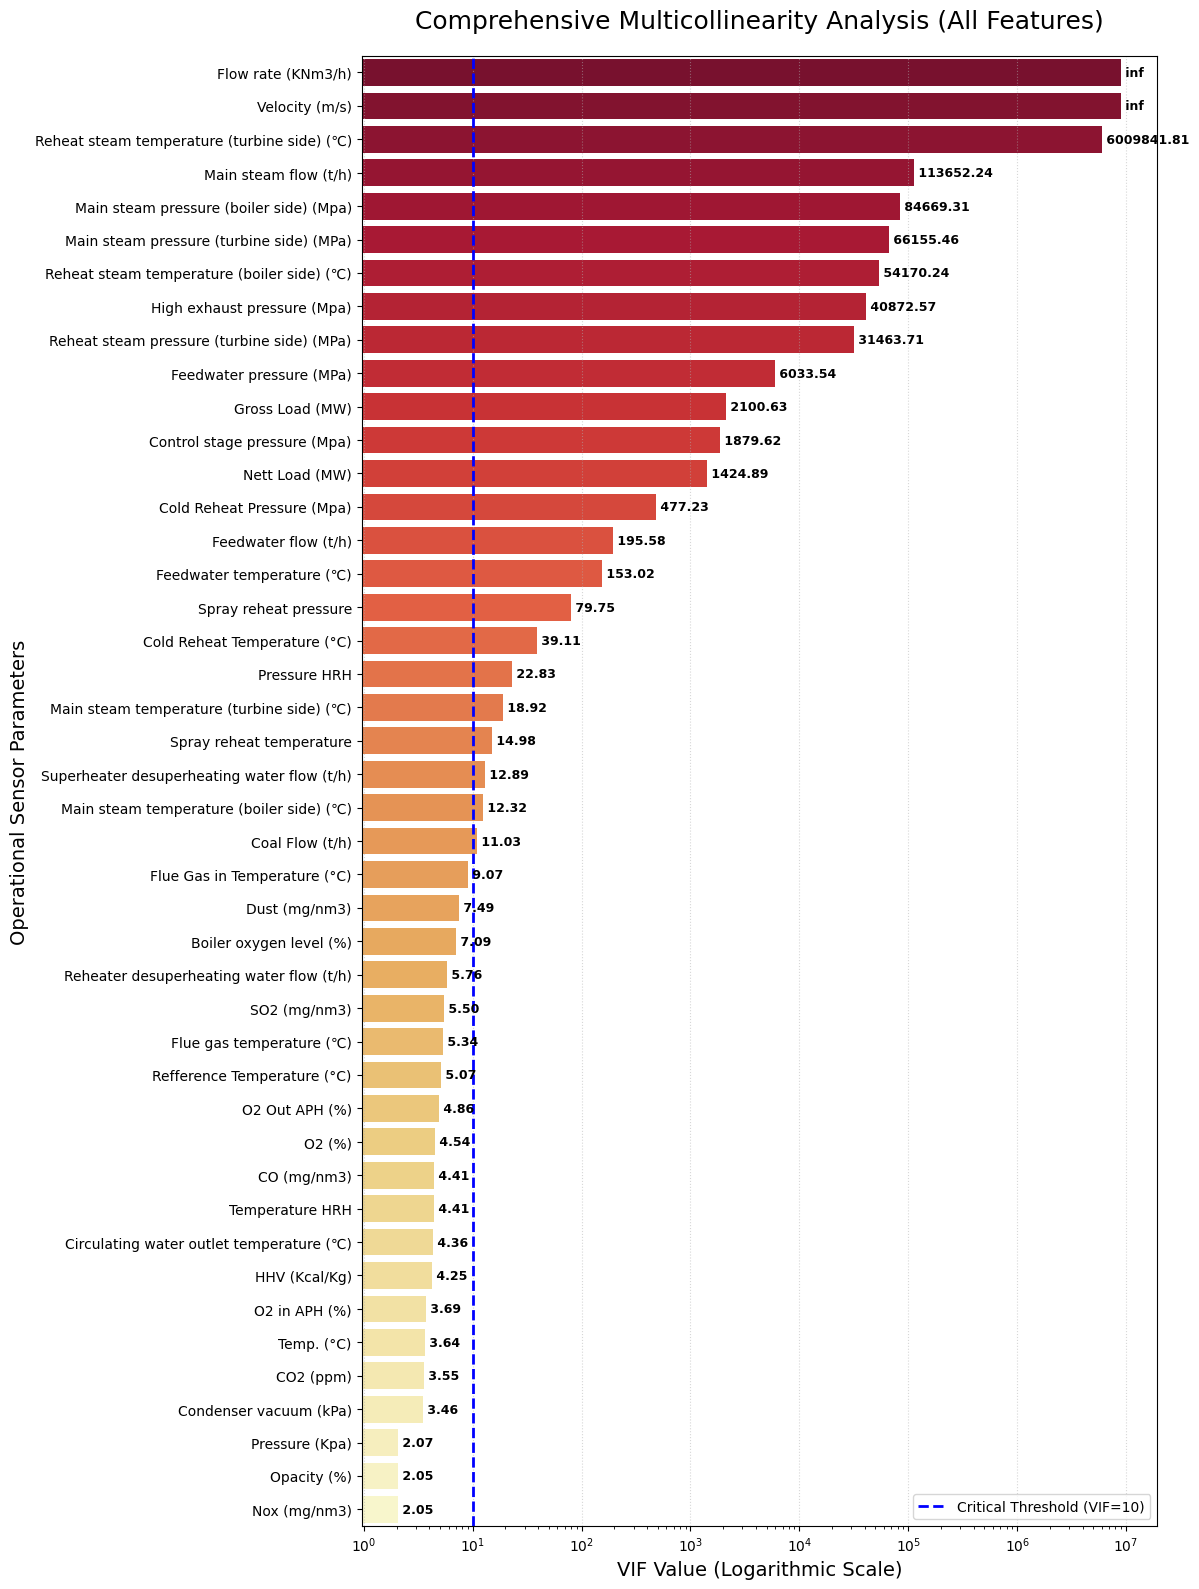

In [13]:
# 2. Mengatasi nilai 'inf' agar bisa tampil di grafik
max_real_vif = vif_results[vif_results['VIF'] != np.inf]['VIF'].max()
vif_results['VIF_Display'] = vif_results['VIF'].replace(np.inf, max_real_vif * 1.5)

# 3. Setup Figure
plt.figure(figsize=(12, 16))

# 4. Plot Bar Chart (PERBAIKAN DI SINI)
# Assign y ke hue dan tambahkan legend=False untuk menghilangkan warning
ax = sns.barplot(
    x='VIF_Display', 
    y='Feature', 
    data=vif_results, 
    palette='YlOrRd_r', 
    hue='Feature',    # Tambahkan ini
    legend=False      # Tambahkan ini
)

# 5. MENGGUNAKAN SKALA LOGARITMIK
plt.xscale('log')

# 6. Menambahkan Garis Threshold VIF=10
plt.axvline(x=10, color='blue', linestyle='--', linewidth=2, label='Critical Threshold (VIF=10)')

# 7. Menambahkan Label Angka di ujung bar
# Menggunakan zip untuk memastikan sinkronisasi data dengan bar
for i, (p, feature_name) in enumerate(zip(ax.patches, vif_results['Feature'])):
    width = p.get_width()
    # Mengambil nilai asli dari dataframe berdasarkan urutan index saat ini
    original_vif = vif_results.iloc[i]['VIF']
    label_text = 'inf' if original_vif == np.inf else f"{original_vif:.2f}"
    
    ax.text(width, p.get_y() + p.get_height()/2, f' {label_text}', 
            va='center', fontsize=9, fontweight='bold')

# 8. Judul dan Label
plt.title('Comprehensive Multicollinearity Analysis (All Features)', fontsize=18, pad=20)
plt.xlabel('VIF Value (Logarithmic Scale)', fontsize=14)
plt.ylabel('Operational Sensor Parameters', fontsize=14)
plt.legend(loc='lower right')
plt.grid(axis='x', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

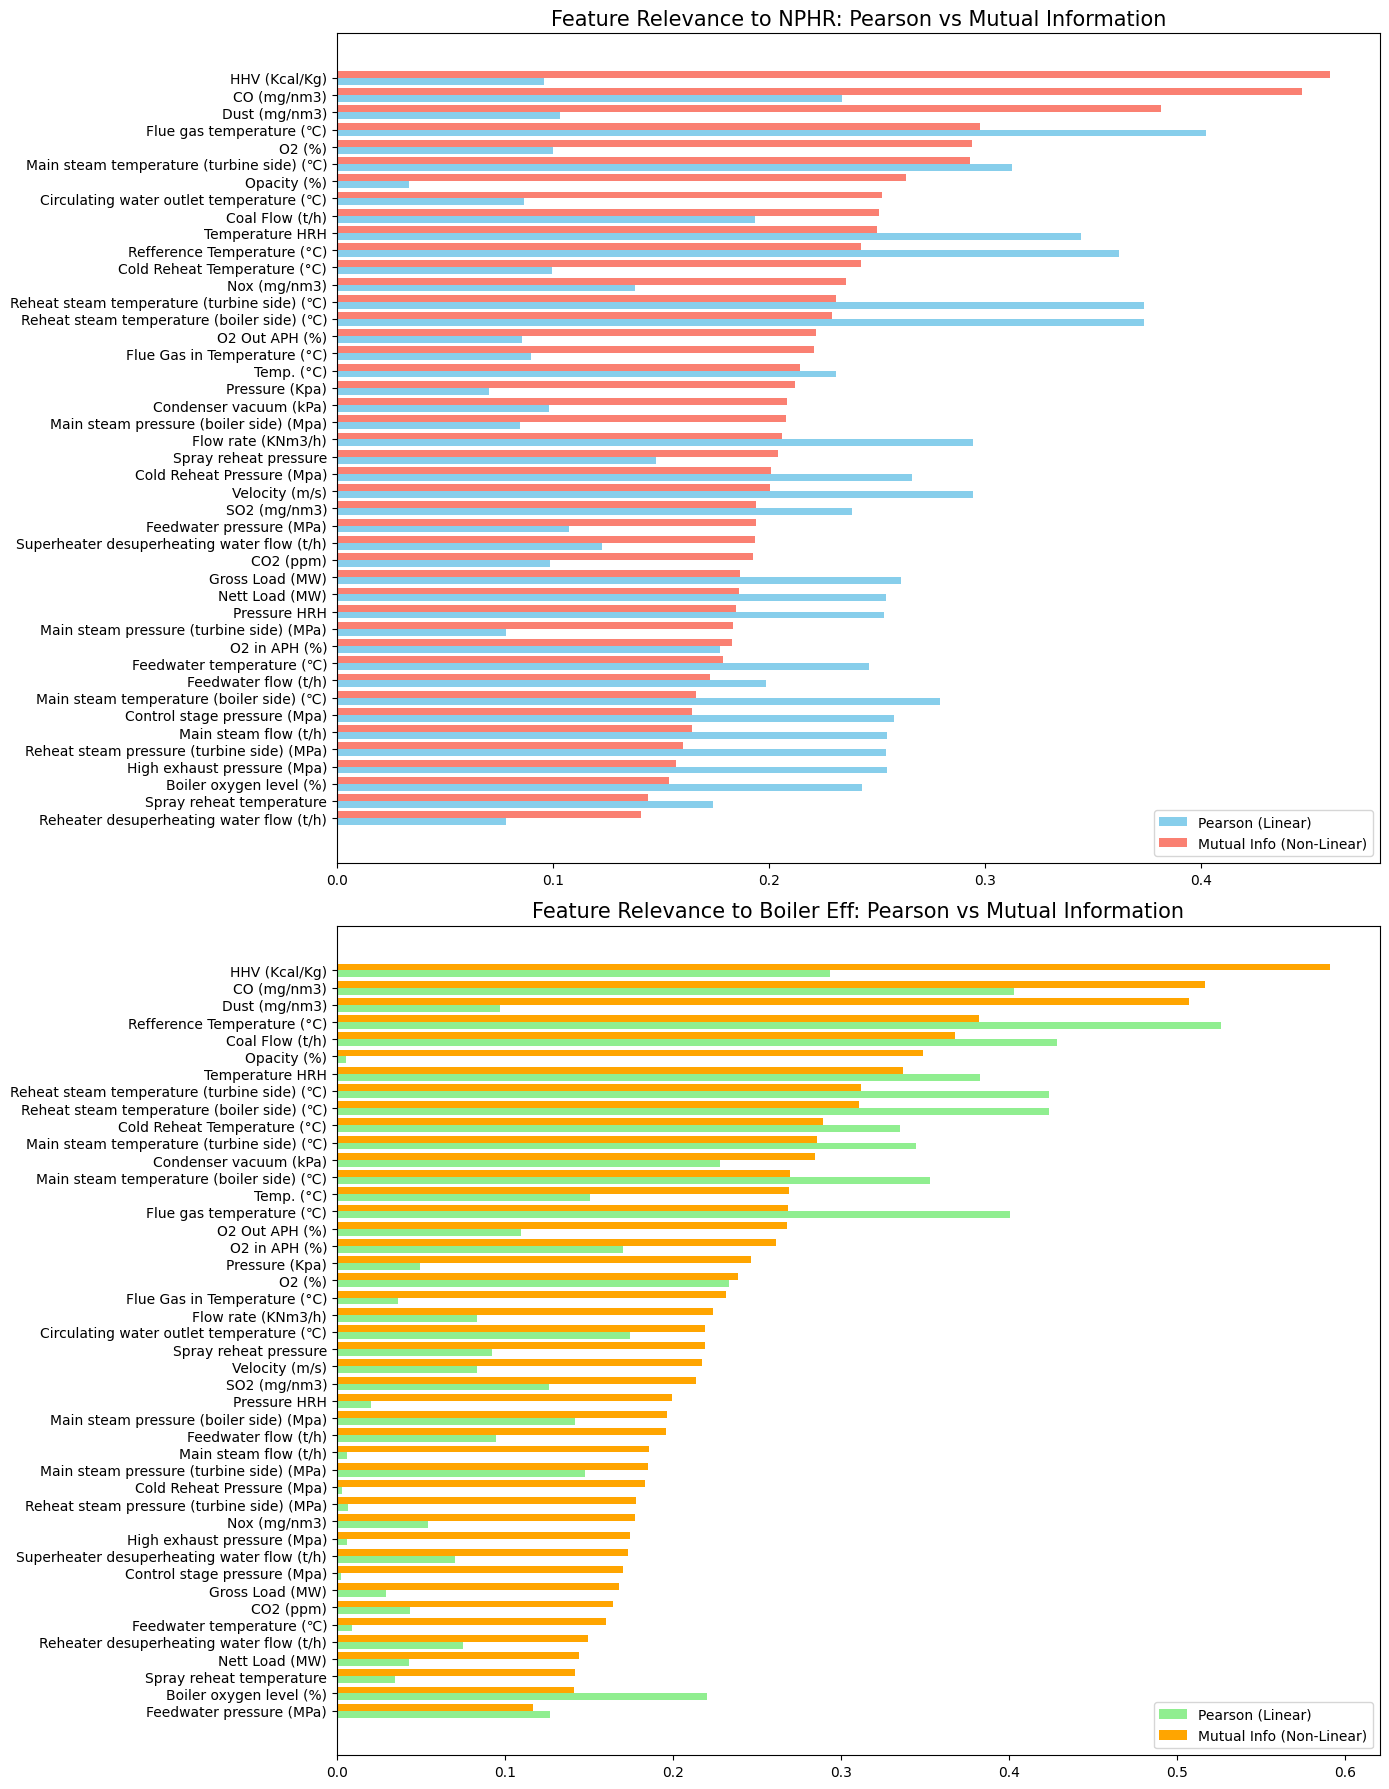

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression

# 1. Load Data
# df_raw_1 sudah didefinisikan sebelumnya
target_cols = ['NPHR (Kcal/Kwh)', 'Boiler Eff (%)']
X = df_raw_1.drop(columns=target_cols)
y_nphr = df_raw_1['NPHR (Kcal/Kwh)']
y_eff = df_raw_1['Boiler Eff (%)']

# 2. Hitung Korelasi Pearson (Linear) terhadap Target
pearson_nphr = X.corrwith(y_nphr).abs()
pearson_eff = X.corrwith(y_eff).abs()

# 3. Hitung Mutual Information (Non-Linear) terhadap Target
# Kita perlu mengisi NaN jika ada agar MI bisa berjalan
X_fill = X.fillna(X.median())
mi_nphr = mutual_info_regression(X_fill, y_nphr, random_state=42)
mi_eff = mutual_info_regression(X_fill, y_eff, random_state=42)

# 4. Gabungkan dalam DataFrame untuk Visualisasi
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Pearson_NPHR': pearson_nphr.values,
    'MI_NPHR': mi_nphr,
    'Pearson_Eff': pearson_eff.values,
    'MI_Eff': mi_eff
}).sort_values(by='MI_NPHR', ascending=False)

# 5. Visualisasi Perbandingan Pearson vs MI (Justifikasi MrMiMaxG)
plt.figure(figsize=(14, 18))

# Subplot 1: Terhadap NPHR
plt.subplot(2, 1, 1)
df_plot_nphr = importance_df.sort_values('MI_NPHR', ascending=True)
y_pos = np.arange(len(df_plot_nphr))
plt.barh(y_pos - 0.2, df_plot_nphr['Pearson_NPHR'], 0.4, label='Pearson (Linear)', color='skyblue')
plt.barh(y_pos + 0.2, df_plot_nphr['MI_NPHR'], 0.4, label='Mutual Info (Non-Linear)', color='salmon')
plt.yticks(y_pos, df_plot_nphr['Feature'])
plt.title('Feature Relevance to NPHR: Pearson vs Mutual Information', fontsize=15)
plt.legend()

# Subplot 2: Terhadap Boiler Efficiency
plt.subplot(2, 1, 2)
df_plot_eff = importance_df.sort_values('MI_Eff', ascending=True)
y_pos = np.arange(len(df_plot_eff))
plt.barh(y_pos - 0.2, df_plot_eff['Pearson_Eff'], 0.4, label='Pearson (Linear)', color='lightgreen')
plt.barh(y_pos + 0.2, df_plot_eff['MI_Eff'], 0.4, label='Mutual Info (Non-Linear)', color='orange')
plt.yticks(y_pos, df_plot_eff['Feature'])
plt.title('Feature Relevance to Boiler Eff: Pearson vs Mutual Information', fontsize=15)
plt.legend()

plt.tight_layout()
plt.show()

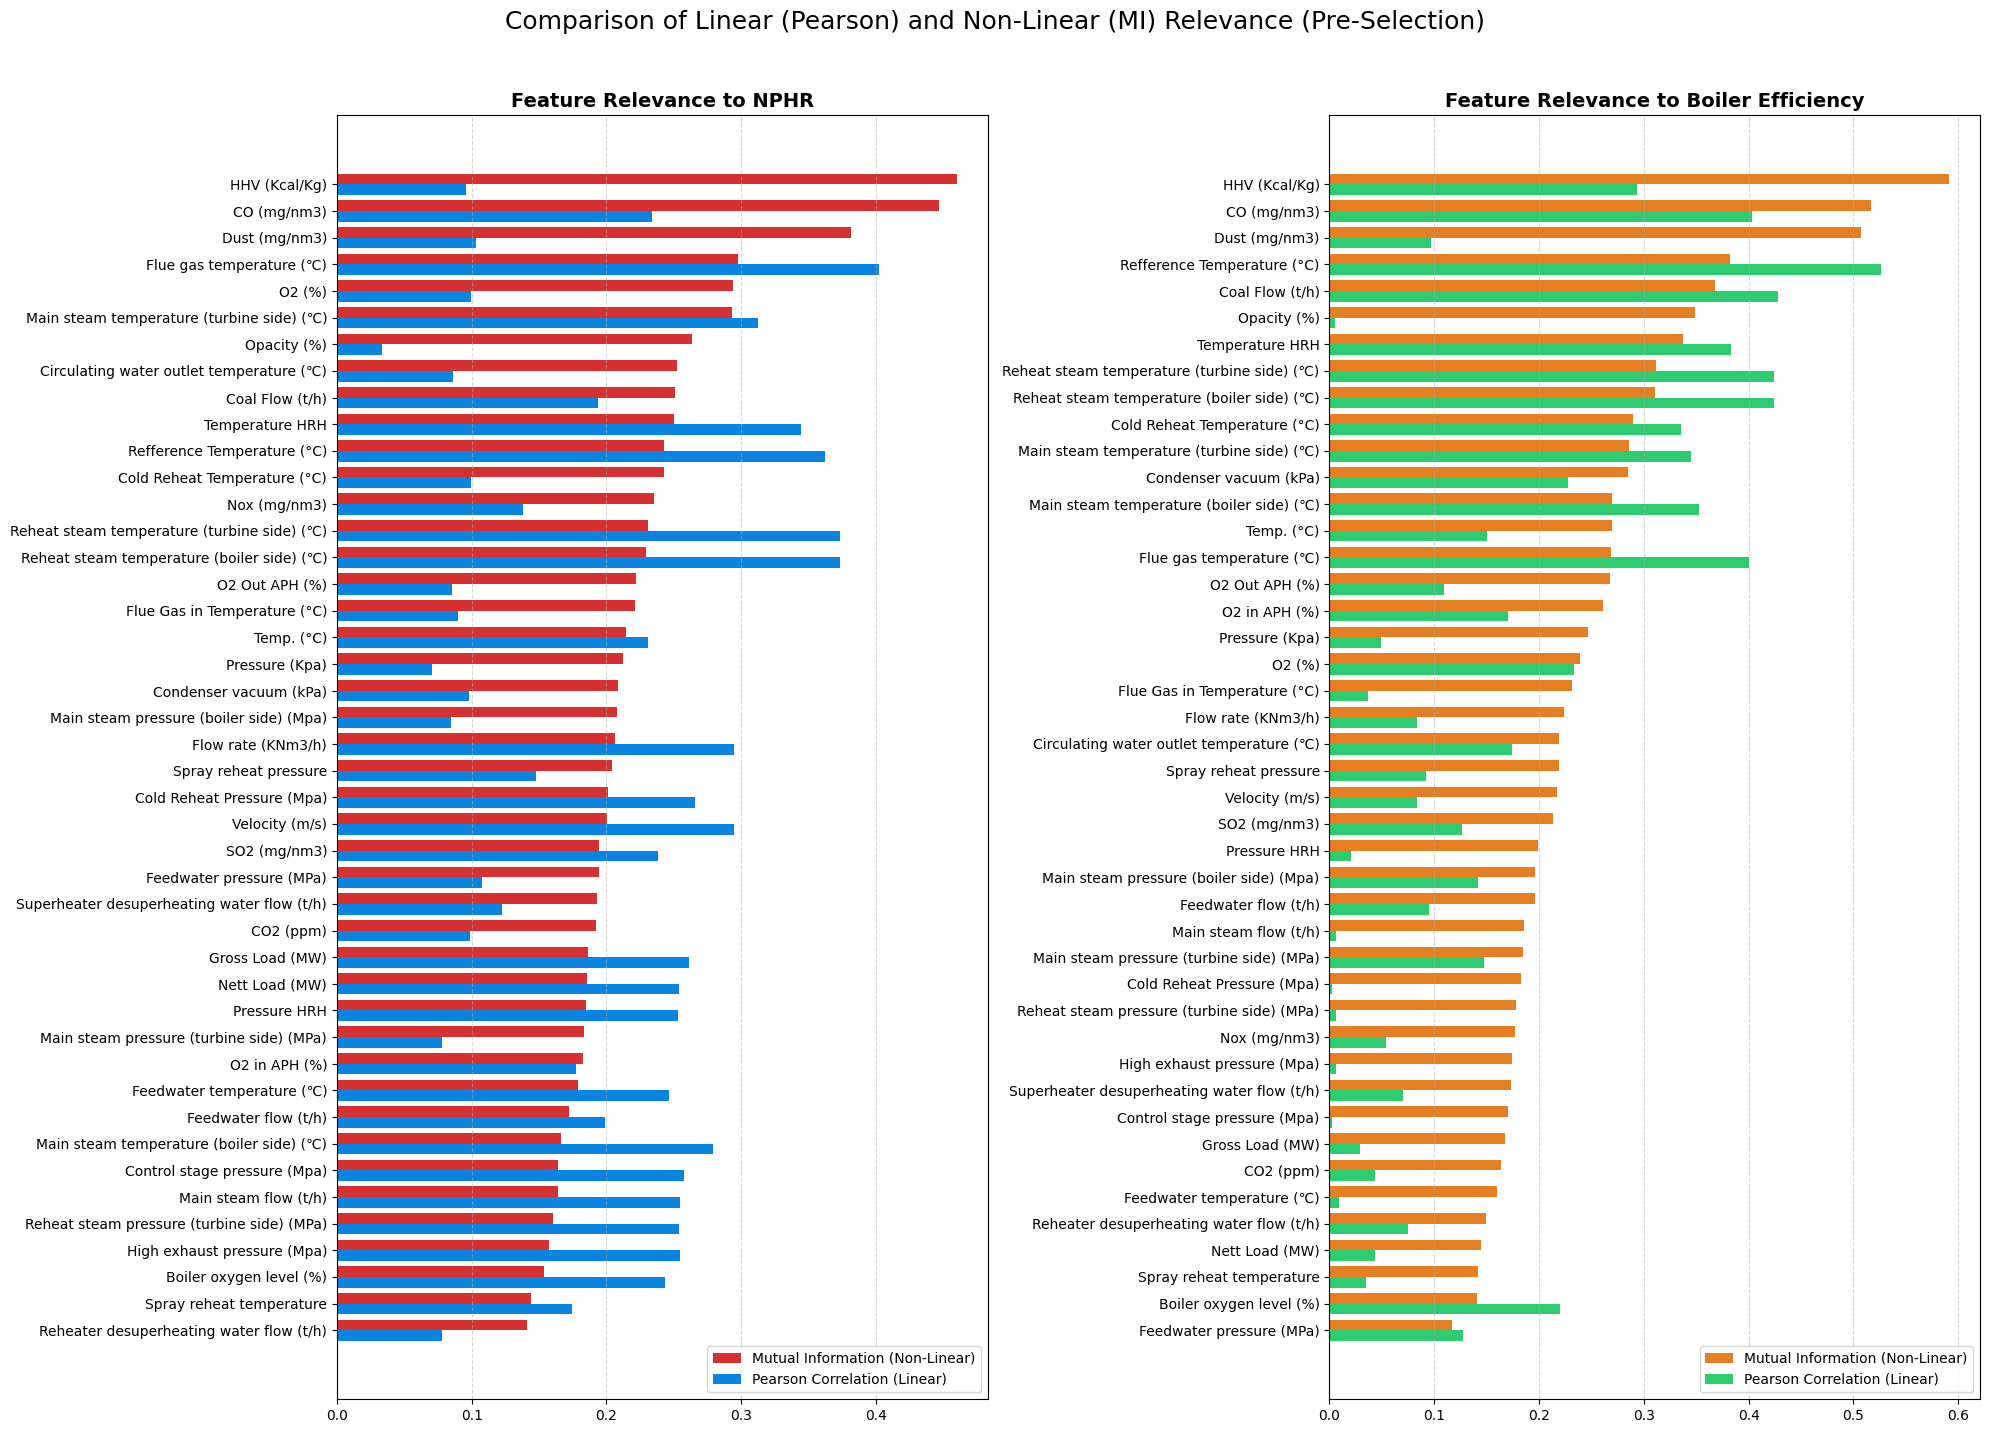

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression

# 1. Persiapan Data
target_cols = ['NPHR (Kcal/Kwh)', 'Boiler Eff (%)']
X = df_raw_1.drop(columns=target_cols)
y_nphr = df_raw_1['NPHR (Kcal/Kwh)']
y_eff = df_raw_1['Boiler Eff (%)']

# Mengisi missing values agar MI tidak error
X_fill = X.fillna(X.median())

# 2. Perhitungan Skor
# Target 1: NPHR
pearson_nphr = X.corrwith(y_nphr).abs()
mi_nphr = mutual_info_regression(X_fill, y_nphr, random_state=42)

# Target 2: Boiler Efficiency
pearson_eff = X.corrwith(y_eff).abs()
mi_eff = mutual_info_regression(X_fill, y_eff, random_state=42)

# 3. Membuat Dataframe Hasil untuk Plotting
df_res = pd.DataFrame({
    'Feature': X.columns,
    'Pearson_NPHR': pearson_nphr.values,
    'MI_NPHR': mi_nphr,
    'Pearson_Eff': pearson_eff.values,
    'MI_Eff': mi_eff
})

# 4. Visualisasi
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 14)) # Menggunakan 1 baris 2 kolom agar mudah dibandingkan

# --- Plot 1: NPHR ---
df_nphr = df_res.sort_values('MI_NPHR', ascending=True)
y_pos = np.arange(len(df_nphr))
ax1.barh(y_pos + 0.2, df_nphr['MI_NPHR'], 0.4, label='Mutual Information (Non-Linear)', color='#d63031')
ax1.barh(y_pos - 0.2, df_nphr['Pearson_NPHR'], 0.4, label='Pearson Correlation (Linear)', color='#0984e3')
ax1.set_yticks(y_pos)
ax1.set_yticklabels(df_nphr['Feature'], fontsize=10)
ax1.set_title('Feature Relevance to NPHR', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right')
ax1.grid(axis='x', linestyle='--', alpha=0.5)

# --- Plot 2: Boiler Efficiency ---
df_eff = df_res.sort_values('MI_Eff', ascending=True)
y_pos = np.arange(len(df_eff))
ax2.barh(y_pos + 0.2, df_eff['MI_Eff'], 0.4, label='Mutual Information (Non-Linear)', color='#e67e22')
ax2.barh(y_pos - 0.2, df_eff['Pearson_Eff'], 0.4, label='Pearson Correlation (Linear)', color='#2ecc71')
ax2.set_yticks(y_pos)
ax2.set_yticklabels(df_eff['Feature'], fontsize=10)
ax2.set_title('Feature Relevance to Boiler Efficiency', fontsize=14, fontweight='bold')
ax2.legend(loc='lower right')
ax2.grid(axis='x', linestyle='--', alpha=0.5)

plt.suptitle('Comparison of Linear (Pearson) and Non-Linear (MI) Relevance (Pre-Selection)', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()